Total connections per node: {1: 2, 2: 3, 3: 3, 4: 2, 5: 2, 6: 3, 7: 3, 8: 2}

The node with the most connections is '2' with 3 connections.


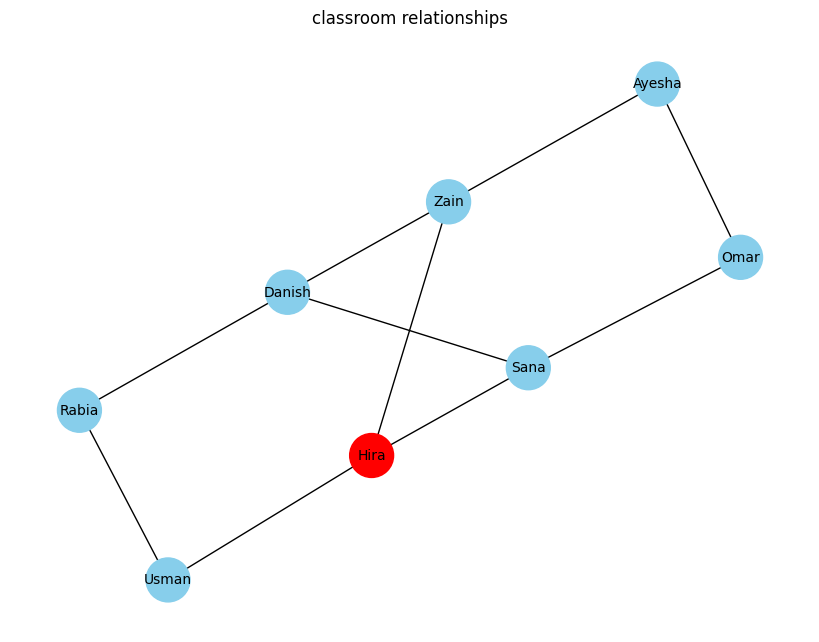

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

classroom = nx.Graph()

classroom.add_node(1, label="Usman")
classroom.add_node(2, label="Hira")
classroom.add_node(3, label="Zain")
classroom.add_node(4, label="Ayesha")
classroom.add_node(5, label="Omar")
classroom.add_node(6, label="Sana")
classroom.add_node(7, label="Danish")
classroom.add_node(8, label="Rabia")

classroom.add_edge(1, 2, title="Usman and Hira")
classroom.add_edge(2, 3, title="Hira and Zain")
classroom.add_edge(3, 4, title="Zain and Ayesha")
classroom.add_edge(4, 5, title="Ayesha and Omar")
classroom.add_edge(5, 6, title="Omar and Sana")
classroom.add_edge(6, 7, title="Sana and Danish")
classroom.add_edge(7, 8, title="Danish and Rabia")
classroom.add_edge(8, 1, title="Rabia and Usman")
classroom.add_edge(2, 6, title="Hira and Sana")
classroom.add_edge(3, 7, title="Zain and Danish")


degree_map = {node: classroom.degree[node] for node in classroom.nodes()}
most_connected_node = max(degree_map, key=degree_map.get)
most_connections = degree_map[most_connected_node]

print(f"Total connections per node: {degree_map}")
print(f"\nThe node with the most connections is '{most_connected_node}' with {most_connections} connections.")


pos = nx.spring_layout(classroom)
labels = nx.get_node_attributes(classroom, 'label')
node_colors = ['red' if node == most_connected_node else 'skyblue' for node in classroom.nodes()]

plt.figure(figsize=(8,6))
nx.draw(classroom, pos, with_labels=True, labels=labels, node_color=node_colors, node_size=1000, font_size=10)
plt.title("classroom relationships")
plt.show()

In [ ]:

from graphviz import Digraph

uni = nx.DiGraph()

uni.add_node("Rector", label="Rector: Dr. Khalid")
uni.add_node("Dean", label="Dean: Ms. Sadaf")
uni.add_node("HoD_Math", label="HoD Math: Dr. Salman")
uni.add_node("HoD_Physics", label="HoD Physics: Dr. Nida")
uni.add_node("Prof_Math1", label="Prof Math: Mr. Usman")
uni.add_node("Prof_Math2", label="Prof Math: Ms. Hina")
uni.add_node("Prof_Physics1", label="Prof Physics: Mr. Tariq")
uni.add_node("Lect_Math", label="Lect Math: Ms. Sana")
uni.add_node("Lab_Assistant", label="Lab Assistant: Mr. Bilal")

uni.add_edges_from([
    ("Rector", "Dean"),
    ("Dean", "HoD_Math"),
    ("Dean", "HoD_Physics"),
    ("HoD_Math", "Prof_Math1"),
    ("HoD_Math", "Prof_Math2"),
    ("HoD_Physics", "Prof_Physics1"),
    ("Prof_Math1", "Lect_Math"),
    ("Lect_Math", "Lab_Assistant"),
])


dot = Digraph(comment="University Hierarchy", format='png')

dot.attr(rankdir='TB')

for node, data in uni.nodes(data=True):
    dot.node(node, data.get('label', node))

for u, v in uni.edges():
    dot.edge(u, v)

dot.render('q2', view=True)

in_degrees = uni.in_degree()
out_degrees = uni.out_degree()
for node in uni.nodes():
    node_in_degree = in_degrees[node]
    node_out_degree = out_degrees[node]
    print(f"Node '{node}': In-degree = {node_in_degree}, Out-degree = {node_out_degree}")

dean_to_leaf_paths = [
    nx.dag_longest_path_length(nx.subgraph(uni, nx.dfs_tree(uni, source="Dean")))
]
hierarchy_depth = max(dean_to_leaf_paths) + 1
print("Hierarchy Depth\n")
print("Longest chain from Dean to a professor", hierarchy_depth, " levels.")


Node 'Rector': In-degree = 0, Out-degree = 1
Node 'Dean': In-degree = 1, Out-degree = 2
Node 'HoD_Math': In-degree = 1, Out-degree = 2
Node 'HoD_Physics': In-degree = 1, Out-degree = 1
Node 'Prof_Math1': In-degree = 1, Out-degree = 1
Node 'Prof_Math2': In-degree = 1, Out-degree = 0
Node 'Prof_Physics1': In-degree = 1, Out-degree = 0
Node 'Lect_Math': In-degree = 1, Out-degree = 1
Node 'Lab_Assistant': In-degree = 1, Out-degree = 0
Hierarchy Depth

Longest chain from Dean to a professor 5  levels.


recommended friends for target and their mutual friend count:
  - Name 'Zain': 2 mutuals
  - Name 'Sana': 1 mutuals
  - Name 'Danish': 1 mutuals
Top 2 Friend Recommendations are:

  - Zain : 2 mutuals
  - Sana : 1 mutuals


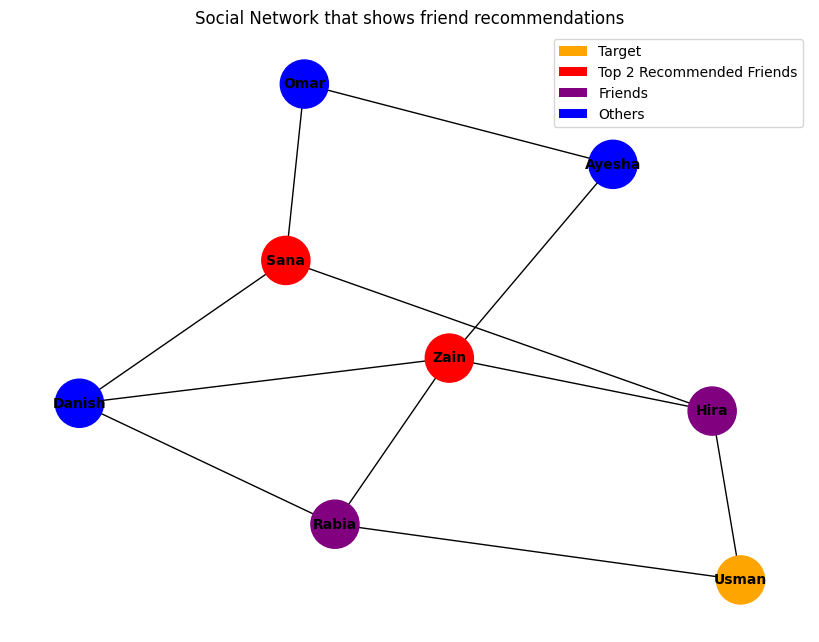

In [24]:


from matplotlib.patches import Patch
socialGraph = nx.Graph()


socialGraph.add_node(1, label="Usman")
socialGraph.add_node(2, label="Hira")
socialGraph.add_node(3, label="Zain")
socialGraph.add_node(4, label="Ayesha")
socialGraph.add_node(5, label="Omar")
socialGraph.add_node(6, label="Sana")
socialGraph.add_node(7, label="Danish")
socialGraph.add_node(8, label="Rabia")

socialGraph.add_edge(1, 2, title="Usman and Hira")
socialGraph.add_edge(2, 3, title="Hira and Zain")
socialGraph.add_edge(3, 4, title="Zain and Ayesha")
socialGraph.add_edge(4, 5, title="Ayesha and Omar")
socialGraph.add_edge(5, 6, title="Omar and Sana")
socialGraph.add_edge(6, 7, title="Sana and Danish")
socialGraph.add_edge(7, 8, title="Danish and Rabia")
socialGraph.add_edge(8, 1, title="Rabia and Usman")
socialGraph.add_edge(8, 3, title="Rabia and Zain")
socialGraph.add_edge(2, 6, title="Hira and Sana")
socialGraph.add_edge(3, 7, title="Zain and Danish")


# the target user id = 1 
targetID = 1

friends_of_target = set(socialGraph.neighbors(targetID))

potential_friends = [
    node for node in socialGraph.nodes() 
    if node != targetID and node not in friends_of_target
]

mutual_friends_count = {}
for potential_friend in potential_friends:
    mutual_count = len(list(nx.common_neighbors(socialGraph, targetID, potential_friend)))
    if mutual_count > 0:
        mutual_friends_count[potential_friend] = mutual_count

print("recommended friends for target and their mutual friend count:")
for user_id, count in mutual_friends_count.items():
    print(f"  - Name '{socialGraph.nodes[user_id]['label']}': {count} mutuals")


recommended_friends = sorted(
    mutual_friends_count,
    key=mutual_friends_count.get,
    reverse=True
)

top_recommendations = recommended_friends[:2]

print("Top 2 Friend Recommendations are:\n")
for rec_id in top_recommendations:
    rec_name = socialGraph.nodes[rec_id]['label']
    print(f"  - {rec_name} : {mutual_friends_count[rec_id]} mutuals")


pos = nx.spring_layout(socialGraph)
labels = nx.get_node_attributes(socialGraph, 'label')
node_colors = []
# the target is orange, 
# tpo 2 recommended friends are red
# friends are purple
# others are blue
for node in socialGraph.nodes():
    if node == targetID:
        node_colors.append('orange')
    elif node in top_recommendations:
        node_colors.append('red')
    elif node in friends_of_target:
        node_colors.append('purple')
    else:
        node_colors.append('blue')

plt.figure(figsize=(8,6))
nx.draw(
    socialGraph, pos, with_labels=True, labels=labels,
    node_color=node_colors, node_size=1200, font_size=10, font_weight='bold'
)
plt.title("Social Network that shows friend recommendations")
legend_elements = [
    Patch(facecolor='orange', label='Target'),
    Patch(facecolor='red', label='Top 2 Recommended Friends'),
    Patch(facecolor='purple', label='Friends'),
    Patch(facecolor='blue', label='Others')
]
plt.legend(handles=legend_elements, loc='best')

plt.show()

